In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve
import matplotlib.pyplot as plt
from scipy.optimize import linprog

In [3]:
df2 = pd.read_csv('cleaneddata_metrics.csv')
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 33 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      400000 non-null  int64  
 1   Unnamed: 0        400000 non-null  int64  
 2   event_id          400000 non-null  int64  
 3   ad_id             400000 non-null  int64  
 4   user_id           400000 non-null  str    
 5   timestamp         400000 non-null  str    
 6   day_of_week       400000 non-null  str    
 7   time_of_day       400000 non-null  str    
 8   event_type        400000 non-null  str    
 9   ad_id:1           400000 non-null  int64  
 10  campaign_id       400000 non-null  int64  
 11  ad_platform       400000 non-null  str    
 12  ad_type           400000 non-null  str    
 13  target_gender     400000 non-null  str    
 14  target_age_group  400000 non-null  str    
 15  target_interests  400000 non-null  str    
 16  campaign_id:1     400000 non-nu

**Target Variable (Y) & Features (X) Chosen**

Y: Conversion (Purchase) or not

X: 4 Categorical Features (Age_Group, Country, Advertisement Type, Day of Week) + 
   3 Numerical Features: CTR, CR and CPA

**Model 1: Logistic Regression**

1) Logistic Regression model chosen due to categorical target variable (Purchase or Not)
2) Class weighting applies due to imbalanced class size (0.5% conversion rate)

In [10]:
# Define features (X)
num_features = ["w_ctr","w_cpa"]
cat_features = ["age_group","country","ad_type","day_of_week"]

# Define X & Y 
X = df2[num_features + cat_features]
Y = df2["purchase"]

# Preprocessing/features transformation (scale for numerical & 1hotencoding for categorical)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

# Logistic Regression with Class Weighting (for imbalanced target variable)
logr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Train/Test Split (70% train, 30% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

# Fit Model
logr.fit(X_train, Y_train)

# Predicting Probability of Purchase (120K output is 30% test dataset, output probabilities is in % terms)
Y_pred = logr.predict_proba(X_test)[:, 1]
Y_pred

array([0.4607992 , 0.52810703, 0.52356557, ..., 0.47221581, 0.5064172 ,
       0.52247164], shape=(120000,))

**Explaining Features' Importance for Model 1**

In [11]:
# Extract Coefficients
coef = logr.named_steps["model"].coef_[0]
features = num_features + list(logr.named_steps["preprocessor"]
                               .transformers_[1][1]
                               .get_feature_names_out(cat_features))
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef,
    "OddsRatio": np.exp(coef)
}).sort_values("Coefficient", key=abs, ascending=False)

print(importance.head(10))

                  Feature  Coefficient  OddsRatio
12          country_japan     0.370042   1.447795
1                   w_cpa    -0.319562   0.726467
13         country_mexico     0.273442   1.314481
9          country_france    -0.234323   0.791106
23    day_of_week_tuesday    -0.207806   0.812364
24  day_of_week_wednesday    -0.132888   0.875563
3         age_group_25-34     0.120586   1.128157
15  country_united states     0.120128   1.127641
4         age_group_35-44     0.115122   1.122010
16          ad_type_image    -0.088465   0.915335


**Coefficient & Odds Ratio Insights** 
1) Japan (odd ratio 1.44), Mexico (1.31) and United States (1.12) have largest positive coefficients & odd ratios means their likelihood to purchase are the highest relative to other countries & features. France (0.79) has negative coefficient, means its users are 21% less likely to purchase as compared to other countries
2) CPA has the largest negative coefficient of -0.31 means for every unit increase will result in the largest decreased probability of purchase relative to other features.
3) Tuesday & Wednesday have negative coefficients, means these days will result in decreased probability of purchase
4) age groups 25-34 & 35-44 have positive coefficients, means they will increase purchase probability

**Calculate Actual Cost per Advertisement Impression**

In [12]:
# Total Advertisment Budget by Campaign ID
Total_AdBudget = round(df2.drop_duplicates(subset=["campaign_id"])["total_budget"].sum(),2)
Total_Impressions = (df2['event_type']=='impression').sum()
Cost_Per_Impression = round(Total_AdBudget / Total_Impressions,2)

print(f"Cost per Ad Impression is ${Cost_Per_Impression}")

Cost per Ad Impression is $7.01


**Comparing Overall Expected & Actual Cost of Acquisition (CPA)**

In [13]:
purchase_prob = logr.predict_proba(X_test)[:, 1]/100    # Convert prob in % into actual value

df_test = X_test.copy()   # 30% test dataset
df_test['purchase_prob'] = purchase_prob    
df_test['spend'] = Cost_Per_Impression = Total_AdBudget / Total_Impressions

total_spend = df_test["spend"].sum()
expected_purchases = df_test["purchase_prob"].sum()   # Expected no.of purchases = Sum of all probabilities
overall_expected_cpa = round(total_spend / expected_purchases,2)  

overall_actual_cpa = df_test['w_cpa'].median()  # use median to exclude outliers' effect at overall lvl
overall_adj_actual_cpa = round(overall_actual_cpa * 3/10,2)  # adjusted for 30% proportion test data used by expected cpa

print(f"Overall Expected CPA is ${overall_expected_cpa} and overall Actual CPA is ${overall_adj_actual_cpa}")

Overall Expected CPA is $1422.38 and overall Actual CPA is $1503.53


**Ad Cost Optimization using Expected CPA & Age_Group Segments**

In [ ]:
# Add Probability of purchase (from model) & Actual Purchase columns onto the original dataset, df2
df2['purchase_prob'] = logr.predict_proba(X)[:, 1]/100    # Convert prob in % into actual value
df2['actual_purchase'] = df2['purchase'].astype(int)   # Convert purchase col datatype from boolean to integer 
df2['ad_budget'] = df2['total_budget'] 

# Creating a new dataframe for the 3 relevant columns
summary1 = df2.groupby('age_group').agg(
    ad_budget = ('ad_budget', 'mean'),
    expected_purchases = ('purchase_prob', 'sum')
    )
# Round the expected purchases to 0 dp
summary1[['expected_purchases','ad_budget']] = summary1[['expected_purchases','ad_budget']].round(0)

# Add Expected CPA column
summary1['expected_cpa'] = round(summary1['ad_budget'] / summary1['expected_purchases'],2)

# Sort entire dataframe by expected cpa col
sorted_summary1 = summary1.sort_values(by='expected_cpa', ascending=False)
sorted_summary1

,ad_budget,expected_purchases,expected_cpa
age_group,,,
55-65,51812.0,16.0,3238.25
45-54,51223.0,63.0,813.06
16-17,51161.0,166.0,308.20
35-44,51174.0,288.0,177.69
18-24,51213.0,612.0,83.68
25-34,51119.0,828.0,61.74


In [36]:
print(f" The median expected cpa for age group segments is ${summary1['expected_cpa'].median()}")

 The median expected cpa for age group segments is $242.945


**Recommendation**
1) Stop/Reduce the ad_budget on those user segments whose expected cost of acquisition (cpa) is lower than that of the median expected cpa for the age segment
2) In this case, since the median expected cpa is $242, can stop ad targeting on the 55-65, 16-17 and 45-54 age groups to optimize digital advertising costs (increase purchases and reduce overall cpa cost). 

**Ad Cost Optimization using Expected CPA & Country Segments**

In [37]:
# Add Probability of purchase (from model) & Actual Purchase columns onto the original dataset, df2
df2['purchase_prob'] = logr.predict_proba(X)[:, 1]/100    # Convert prob in % into actual value
df2['actual_purchase'] = df2['purchase'].astype(int)   # Convert purchase col datatype from boolean to integer 
df2['ad_budget'] = df2['total_budget'] 

# Creating a new dataframe for the 3 relevant columns
summary2 = df2.groupby('country').agg(
    ad_budget = ('ad_budget', 'mean'),
    expected_purchases = ('purchase_prob', 'sum')
    )
# Round the expected purchases to 0 dp
summary2[['expected_purchases','ad_budget']] = summary2[['expected_purchases','ad_budget']].round(0)

# Add Expected CPA column
summary2['expected_cpa'] = round(summary2['ad_budget'] / summary2['expected_purchases'],2)

# Sort entire dataframe by expected cpa col
sorted_summary2 = summary2.sort_values(by='expected_cpa', ascending=False)
sorted_summary2

,ad_budget,expected_purchases,expected_cpa
country,,,
france,51397.0,65.0,790.72
mexico,51174.0,112.0,456.91
japan,51068.0,112.0,455.96
brazil,50911.0,118.0,431.45
australia,51302.0,138.0,371.75
germany,51371.0,151.0,340.21
india,51080.0,183.0,279.13
canada,51057.0,194.0,263.18
united kingdom,51080.0,281.0,181.78


In [38]:
print(f" The median expected cpa for country segments is ${summary2['expected_cpa'].median()}")

 The median expected cpa for country segments is $355.98


**Recommendations**
1) Stop/Reduce the ad_budget on those user segments whose expected cost of acquisition (cpa) is lower than that of the median expected cpa for the countries segment
2) In this case, since the median expected cpa is $356, can focus ad targeting for users located in USA, UK,Canada, India & Germany to optimize digital advertising costs (increase purchases and reduce overall cpa cost).

**Ad Cost Optimization using Expected CPA & Advertisement Type Segments**

In [39]:
# Add Probability of purchase (from model) & Actual Purchase columns onto the original dataset, df2
df2['purchase_prob'] = logr.predict_proba(X)[:, 1]/100    # Convert prob in % into actual value
df2['actual_purchase'] = df2['purchase'].astype(int)   # Convert purchase col datatype from boolean to integer 
df2['ad_budget'] = df2['total_budget'] 

# Creating a new dataframe for the 3 relevant columns
summary3 = df2.groupby('ad_type').agg(
    ad_budget = ('ad_budget', 'mean'),
    expected_purchases = ('purchase_prob', 'sum')
    )
# Round the expected purchases to 0 dp
summary3[['expected_purchases','ad_budget']] = summary3[['expected_purchases','ad_budget']].round(0)

# Add Expected CPA column
summary3['expected_cpa'] = round(summary3['ad_budget'] / summary3['expected_purchases'],2)

# Sort entire dataframe by expected cpa col
sorted_summary3 = summary3.sort_values(by='expected_cpa', ascending=False)
sorted_summary3

,ad_budget,expected_purchases,expected_cpa
ad_type,,,
video,49530.0,325.0,152.40
image,55975.0,492.0,113.77
carousel,53090.0,516.0,102.89
stories,46597.0,638.0,73.04


In [40]:
print(f" The median expected cpa for advertising type segments is ${summary3['expected_cpa'].median()}")

 The median expected cpa for advertising type segments is $108.33


**Recommendations**
1) Stop/Reduce the ad_budget on those user segments whose expected cost of acquisition (cpa) is lower than that of the median expected cpa for the advertisement type segments
2) In this case, since the median expected cpa is $108, can focus ad targeting using stories and carousel ad types in order to optimize digital advertising costs (increase purchases and reduce overall cpa cost).

**Comparing Actual vs Expected CPA (by decile) on 30% test dataset**

In [ ]:
purchase_prob = logr.predict_proba(X_test)[:, 1]/100
df_test = X_test.copy()
df_test['purchase_prob'] = purchase_prob
df_test['spend'] = Cost_Per_Impression = Total_AdBudget / Total_Impressions
df_test['expected_cpa'] = Cost_Per_Impression / purchase_prob   # cpa per impression shows efficiency differences
df_test['actual_cpa'] = df_test['w_cpa']

df_test["decile"] = pd.qcut(df_test["purchase_prob"], 10, labels=False)+1

decile_summary = df_test.groupby("decile").agg(
    expected_cpa = ('expected_cpa','mean'),    # use mean to show skewness & inefficiency at per decile lvl
    actual_cpa = ("actual_cpa", "mean")  # use mean to show skewness & inefficiency at per decile lvl
).reset_index()

# Adjust Actual CPA formula for 30% test data proportion 
decile_summary['adj_actual_cpa'] = decile_summary['actual_cpa'] *3/10

# Adding Actual vs Expected CPA Variance (%) column
decile_summary["variance_%"] = (decile_summary["expected_cpa"] - decile_summary["adj_actual_cpa"])/ decile_summary["adj_actual_cpa"] * 100

# Hide Actual CPA (unadjusted) column
d2 = decile_summary [['decile','expected_cpa','adj_actual_cpa','variance_%']]
d2 = d2.round(2)

print(d2)

   decile  expected_cpa  adj_actual_cpa  variance_%
0       1       3305.63         5229.57      -36.79
1       2       1584.08         2303.22      -31.22
2       3       1511.40         1940.51      -22.11
3       4       1462.81         1714.04      -14.66
4       5       1423.63         1560.67       -8.78
5       6       1389.24         1383.79        0.39
6       7       1355.15         1233.42        9.87
7       8       1319.77         1110.52       18.84
8       9       1277.23          965.59       32.27
9      10       1199.85          865.97       38.56


**Evaluating Model 1 (Logistic Regression) Performance**

In [7]:
Y_pred_labels = (Y_pred >= 0.5).astype(int) 

print(classification_report(Y_test, Y_pred_labels))

              precision    recall  f1-score   support

           0       1.00      0.51      0.67    119391
           1       0.01      0.54      0.01       609

    accuracy                           0.51    120000
   macro avg       0.50      0.52      0.34    120000
weighted avg       0.99      0.51      0.67    120000



**Model 1 Findings**

Macro Avg Precision score is 0.50, recall score is 0.52 and F1 score of 0.34 as shown in the above Classification table. These scores are considered low, but it is affected by the imbalanced class (conversion rate) of 0.5%. Hence the model results are not unexpected

**Model 1 Confusion Matrix Display**

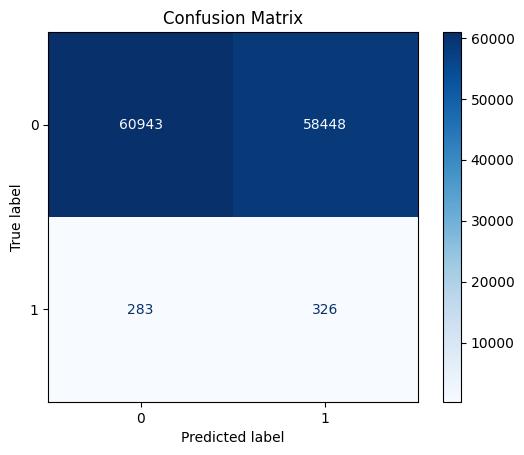

In [8]:
cm = confusion_matrix(Y_test, Y_pred_labels)
# print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_labels))

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix")
plt.show()

**Feature Engineering (using 1 numerical & 1 categorical features)**

In [ ]:
# Define features (X2)
num_features = ["w_cpa"]
cat_features = ["country"]

# Define X2 & Y2
X2 = df2[num_features + cat_features]
Y2 = df2["purchase"]

# Preprocessing/features transformation (scale for numerical & 1hotencoding for categorical)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

# Logistic Regression with Class Weighting (for imbalanced target variable)
logr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Train/Test Split (70% train, 30% test)
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.3, random_state=42, stratify=Y)

# Fit Model
logr.fit(X2_train, Y2_train)

# Predicting Probability of Purchase (120K output is 30% test dataset, output probabilities is in % terms)
Y2_pred = logr.predict_proba(X2_test)[:, 1]
Y2_pred

array([0.44371343, 0.51285121, 0.5088516 , ..., 0.43652573, 0.51461569,
       0.49832732], shape=(120000,))

In [20]:
Y2_pred_labels = (Y2_pred >= 0.5).astype(int) 

print(classification_report(Y2_test, Y2_pred_labels))

              precision    recall  f1-score   support

           0       1.00      0.50      0.66    119391
           1       0.01      0.56      0.01       609

    accuracy                           0.50    120000
   macro avg       0.50      0.53      0.34    120000
weighted avg       0.99      0.50      0.66    120000



**Finding**

There is a decrease in the purchase probabilities (as shown in the above array) as compared to the original features. However, there is no change in model performance